# Laptop price prediction

In [2]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('Datasets/laptops.csv')
df.head(10)

,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,NaN,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,NaN,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8,256,SSD,NaN,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,16,1000,SSD,RTX 3050,15.6,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16,512,SSD,NaN,15.6,No,669.01
5,MSI Crosshair 17 C12VF-264XES Intel Core i7-12...,New,MSI,Crosshair,Intel Core i7,32,1000,SSD,RTX 4060,17.3,No,1699.00
6,Lenovo Thinkpad E14 Gen 4 AMD Ryzen 5 5625U/8G...,New,Lenovo,ThinkPad,AMD Ryzen 5,8,256,SSD,NaN,14.0,No,909.00
7,ASUS VivoBook 15 F515JA-EJ2882W Intel Core i7-...,New,Asus,VivoBook,Intel Core i7,8,512,SSD,NaN,15.6,No,809.01
8,Medion Akoya E15415 Intel Core i5-10210U/8GB/2...,New,Medion,Akoya,Intel Core i5,8,256,SSD,NaN,15.6,No,519.00
9,HP Victus 16-d1038ns Intel Core i7-12700H/16GB...,New,HP,Victus,Intel Core i7,16,512,SSD,RTX 3050,16.1,No,1149.00


In [11]:
df.columns = df.columns.str.lower().str.replace('-', '_')

In [12]:
df.head()

,laptop,status,brand,model,cpu,ram,storage,storage_type,gpu,screen,touch,final_price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,NaN,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,NaN,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8,256,SSD,NaN,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,16,1000,SSD,RTX 3050,15.6,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16,512,SSD,NaN,15.6,No,669.01


In [13]:
cols = ['ram', 'storage', 'screen', 'final_price']

In [14]:
df = df[cols]

# EDA

<Axes: xlabel='final_price', ylabel='Count'>

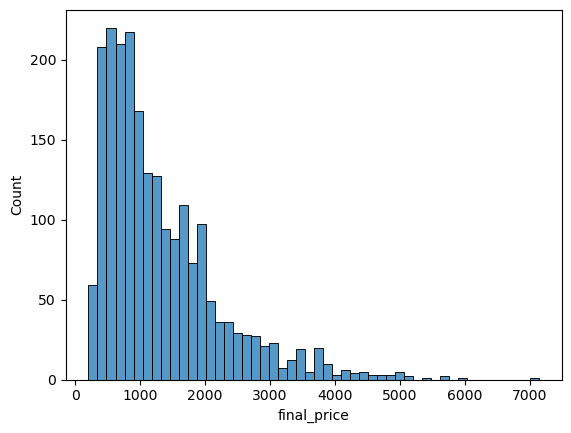

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df.final_price, bins=50) 

In [25]:
df.isnull().sum()

ram            0
storage        0
screen         4
final_price    0
dtype: int64

In [28]:
df.median()

ram              16.000
storage         512.000
screen           15.600
final_price    1031.945
dtype: float64

In [29]:
np.random.seed(42)
idx = np.arange(len(df))
np.random.shuffle(idx)
df = df.iloc[idx]

In [33]:
#Split
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val -n_test

In [35]:
df_train = df.iloc[: n_train]
df_val = df.iloc[n_train : n_train+n_val]
df_test = df.iloc[n_train + n_val : ]

In [36]:
n_train, n_val, n_test

(1296, 432, 432)

In [43]:
df.isnull().sum()

ram            0
storage        0
screen         4
final_price    0
dtype: int64

In [44]:
df.dtypes

ram              int64
storage          int64
screen         float64
final_price    float64
dtype: object

# Filling missing values with zeros